# XAU Depth Volatility Analysis

Notebook này đọc dữ liệu `XAU` từ SQLite, bung `depth_bands_json` thành bảng theo các band `0.5, 1, 1.5, 2, 3, 4, 5`, rồi tập trung đo và vẽ biến động depth ở tần suất 1 giây.

Các câu hỏi chính:
- Depth của từng band thay đổi mạnh hay nhẹ theo thời gian.
- Band nào biến động nhất.
- Biến động depth có đi cùng spread và mid-price hay không.

In [17]:
from __future__ import annotations

import json
import sqlite3
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


In [ ]:
ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

DB_PATH = ROOT / "data" / "snapshots.db"
MARKET = "XAU"
DEPTH_BANDS = [0.5, 1, 1.5, 2, 3, 4, 5]
TIMEZONE = "Asia/Ho_Chi_Minh"
ROLLING_WINDOWS = {
    "30s": 30,
    "60s": 60,
    "300s": 300,
}
DEFAULT_ROLLING_WINDOW = "60s"
KEY_BANDS = [0.5, 1, 1.5, 2, 5]
CONTEXT_BAND = 1
DEFAULT_LOOKBACK = pd.Timedelta(days=7)

# Override these two values to evaluate a custom time range.
now_utc = pd.Timestamp.now(tz="UTC")
endTs = int(now_utc.timestamp() * 1000)
startTs = int((now_utc - DEFAULT_LOOKBACK).timestamp() * 1000)

assert startTs < endTs, "startTs must be smaller than endTs"
assert DB_PATH.exists(), f"Database not found: {DB_PATH}"
DEFAULT_WINDOW_SIZE = ROLLING_WINDOWS[DEFAULT_ROLLING_WINDOW]
DB_PATH

PosixPath('/Users/trungnguyen/Desktop/oraichain/lighter-orderbook-snapshot/data/snapshots.db')

## Load and flatten data

In [19]:
query = """
SELECT
    ts_ms,
    market,
    best_bid,
    best_ask,
    spread,
    mid_price,
    depth_bands_json
FROM snapshots
WHERE market = ?
  AND ts_ms BETWEEN ? AND ?
ORDER BY ts_ms ASC
"""

with sqlite3.connect(DB_PATH) as conn:
    raw_df = pd.read_sql_query(query, conn, params=(MARKET, startTs, endTs))

if raw_df.empty:
    raise ValueError(
        f"No rows found for market={MARKET} in range startTs={startTs}, endTs={endTs}"
    )

raw_df["timestamp"] = pd.to_datetime(raw_df["ts_ms"], unit="ms", utc=True).dt.tz_convert(TIMEZONE)
raw_df["depth_bands"] = raw_df["depth_bands_json"].apply(json.loads)
raw_df = raw_df.drop(columns=["depth_bands_json"])
raw_df.head()

,ts_ms,market,best_bid,best_ask,spread,mid_price,timestamp,depth_bands
0,1776609631523,XAU,NaN,NaN,NaN,NaN,2026-04-19 21:40:31.523000+07:00,[]
1,1776609632524,XAU,4803.69,4803.70,0.01,4803.695,2026-04-19 21:40:32.524000+07:00,"[{'band': 0.5, 'bidDepth': 0.5453, 'askDepth':..."
2,1776609633525,XAU,4803.69,4803.89,0.20,4803.790,2026-04-19 21:40:33.525000+07:00,"[{'band': 0.5, 'bidDepth': 0.24530000000000002..."
3,1776609634525,XAU,4803.88,4803.89,0.01,4803.885,2026-04-19 21:40:34.525000+07:00,"[{'band': 0.5, 'bidDepth': 5.8854999999999995,..."
4,1776609635526,XAU,4803.88,4803.89,0.01,4803.885,2026-04-19 21:40:35.526000+07:00,"[{'band': 0.5, 'bidDepth': 5.8854999999999995,..."


In [20]:
def band_label(band: float) -> str:
    return str(band).replace(".", "_")


def flatten_depth_bands(df: pd.DataFrame, expected_bands: list[float]) -> pd.DataFrame:
    records: list[dict[str, float]] = []

    for depth_items in df["depth_bands"]:
        row: dict[str, float] = {}
        by_band = {float(item["band"]): item for item in depth_items}

        for band in expected_bands:
            item = by_band.get(float(band), {})
            suffix = band_label(band)
            row[f"bid_depth_{suffix}"] = item.get("bidDepth", np.nan)
            row[f"ask_depth_{suffix}"] = item.get("askDepth", np.nan)
            row[f"total_depth_{suffix}"] = item.get("totalDepth", np.nan)

        records.append(row)

    flat_df = pd.DataFrame.from_records(records, index=df.index)
    result = pd.concat([df.drop(columns=["depth_bands"]), flat_df], axis=1)
    return result.sort_values("timestamp").reset_index(drop=True)


df = flatten_depth_bands(raw_df, DEPTH_BANDS)
df.head()

,ts_ms,market,best_bid,best_ask,spread,mid_price,timestamp,bid_depth_0_5,ask_depth_0_5,total_depth_0_5,bid_depth_1,ask_depth_1,total_depth_1,bid_depth_1_5,ask_depth_1_5,total_depth_1_5,bid_depth_2,ask_depth_2,total_depth_2,bid_depth_3,ask_depth_3,total_depth_3,bid_depth_4,ask_depth_4,total_depth_4,bid_depth_5,ask_depth_5,total_depth_5
0,1776609631523,XAU,NaN,NaN,NaN,NaN,2026-04-19 21:40:31.523000+07:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1776609632524,XAU,4803.69,4803.70,0.01,4803.695,2026-04-19 21:40:32.524000+07:00,0.5453,0.1393,0.6846,4.7086,0.1393,4.8479,7.9426,2.1251,10.0677,10.2285,7.8450,18.0735,16.7328,13.3924,30.1252,22.0471,25.4415,47.4886,22.3471,29.0751,51.4222
2,1776609633525,XAU,4803.69,4803.89,0.20,4803.790,2026-04-19 21:40:33.525000+07:00,0.2453,0.1393,0.3846,4.4086,0.1393,4.5479,7.6426,4.0109,11.6535,9.9285,8.1631,18.0916,16.4328,21.7797,38.2125,21.7471,25.9619,47.7090,22.0471,34.9905,57.0376
3,1776609634525,XAU,4803.88,4803.89,0.01,4803.885,2026-04-19 21:40:34.525000+07:00,5.8855,0.1393,6.0248,5.8855,0.1393,6.0248,7.9195,4.0109,11.9304,9.9798,8.1631,18.1429,16.1841,21.7797,37.9638,21.7984,25.9619,47.7603,21.7984,34.9905,56.7889
4,1776609635526,XAU,4803.88,4803.89,0.01,4803.885,2026-04-19 21:40:35.526000+07:00,5.8855,0.1393,6.0248,5.8855,0.1393,6.0248,7.9195,4.0109,11.9304,9.9798,8.1631,18.1429,16.1841,21.7797,37.9638,21.7984,25.9619,47.7603,21.7984,34.9905,56.7889


## Data quality checks

In [21]:
missing_band_rows = []
for band in DEPTH_BANDS:
    suffix = band_label(band)
    total_col = f"total_depth_{suffix}"
    if df[total_col].isna().any():
        missing_band_rows.append(band)

consistency_checks = []
for band in DEPTH_BANDS:
    suffix = band_label(band)
    total_col = f"total_depth_{suffix}"
    bid_col = f"bid_depth_{suffix}"
    ask_col = f"ask_depth_{suffix}"
    max_error = (df[total_col] - (df[bid_col] + df[ask_col])).abs().max()
    consistency_checks.append({"band": band, "max_total_error": max_error})

quality_summary = {
    "row_count": int(len(df)),
    "timestamp_start": df["timestamp"].min(),
    "timestamp_end": df["timestamp"].max(),
    "missing_band_rows": missing_band_rows,
}

quality_summary, pd.DataFrame(consistency_checks)

({'row_count': 2046,
  'timestamp_start': Timestamp('2026-04-19 21:40:31.523000+0700', tz='Asia/Ho_Chi_Minh'),
  'timestamp_end': Timestamp('2026-04-19 22:16:20.078000+0700', tz='Asia/Ho_Chi_Minh'),
  'missing_band_rows': [0.5, 1, 1.5, 2, 3, 4, 5]},
    band  max_total_error
 0   0.5              0.0
 1   1.0              0.0
 2   1.5              0.0
 3   2.0              0.0
 4   3.0              0.0
 5   4.0              0.0
 6   5.0              0.0)

## Volatility features

In [22]:
for band in DEPTH_BANDS:
    suffix = band_label(band)
    total_col = f"total_depth_{suffix}"
    bid_col = f"bid_depth_{suffix}"
    ask_col = f"ask_depth_{suffix}"

    delta_col = f"depth_change_1s_{suffix}"
    abs_delta_col = f"abs_depth_change_1s_{suffix}"
    return_col = f"depth_return_1s_{suffix}"
    rolling_std_col = f"rolling_std_{DEFAULT_ROLLING_WINDOW}_{suffix}"
    rolling_mean_abs_col = f"rolling_mean_abs_change_{DEFAULT_ROLLING_WINDOW}_{suffix}"
    zscore_col = f"depth_zscore_{DEFAULT_ROLLING_WINDOW}_{suffix}"
    imbalance_col = f"imbalance_{suffix}"

    df[delta_col] = df[total_col].diff()
    df[abs_delta_col] = df[delta_col].abs()
    prev_total = df[total_col].shift(1)
    df[return_col] = np.where(prev_total.gt(0), df[delta_col] / prev_total, np.nan)
    df[rolling_std_col] = df[total_col].rolling(DEFAULT_WINDOW_SIZE, min_periods=5).std()
    df[rolling_mean_abs_col] = df[abs_delta_col].rolling(DEFAULT_WINDOW_SIZE, min_periods=5).mean()

    rolling_mean = df[total_col].rolling(DEFAULT_WINDOW_SIZE, min_periods=5).mean()
    rolling_std = df[rolling_std_col]
    df[zscore_col] = np.where(rolling_std.gt(0), (df[total_col] - rolling_mean) / rolling_std, np.nan)

    total_bid_ask = df[bid_col] + df[ask_col]
    df[imbalance_col] = np.where(total_bid_ask.gt(0), (df[bid_col] - df[ask_col]) / total_bid_ask, np.nan)

df["mid_price_return_1s"] = df["mid_price"].pct_change()
df["mid_price_abs_change_1s"] = df["mid_price"].diff().abs()
df["spread_rolling_std_60s"] = df["spread"].rolling(DEFAULT_WINDOW_SIZE, min_periods=5).std()
df.head()

,ts_ms,market,best_bid,best_ask,spread,mid_price,timestamp,bid_depth_0_5,ask_depth_0_5,total_depth_0_5,bid_depth_1,ask_depth_1,total_depth_1,bid_depth_1_5,ask_depth_1_5,total_depth_1_5,bid_depth_2,ask_depth_2,total_depth_2,bid_depth_3,ask_depth_3,total_depth_3,bid_depth_4,ask_depth_4,total_depth_4,bid_depth_5,ask_depth_5,total_depth_5,depth_change_1s_0_5,abs_depth_change_1s_0_5,depth_return_1s_0_5,rolling_std_60s_0_5,rolling_mean_abs_change_60s_0_5,depth_zscore_60s_0_5,imbalance_0_5,depth_change_1s_1,abs_depth_change_1s_1,depth_return_1s_1,rolling_std_60s_1,rolling_mean_abs_change_60s_1,depth_zscore_60s_1,imbalance_1,depth_change_1s_1_5,abs_depth_change_1s_1_5,depth_return_1s_1_5,rolling_std_60s_1_5,rolling_mean_abs_change_60s_1_5,depth_zscore_60s_1_5,imbalance_1_5,depth_change_1s_2,abs_depth_change_1s_2,depth_return_1s_2,rolling_std_60s_2,rolling_mean_abs_change_60s_2,depth_zscore_60s_2,imbalance_2,depth_change_1s_3,abs_depth_change_1s_3,depth_return_1s_3,rolling_std_60s_3,rolling_mean_abs_change_60s_3,depth_zscore_60s_3,imbalance_3,depth_change_1s_4,abs_depth_change_1s_4,depth_return_1s_4,rolling_std_60s_4,rolling_mean_abs_change_60s_4,depth_zscore_60s_4,imbalance_4,depth_change_1s_5,abs_depth_change_1s_5,depth_return_1s_5,rolling_std_60s_5,rolling_mean_abs_change_60s_5,depth_zscore_60s_5,imbalance_5,mid_price_return_1s,mid_price_abs_change_1s,spread_rolling_std_60s
0,1776609631523,XAU,NaN,NaN,NaN,NaN,2026-04-19 21:40:31.523000+07:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1776609632524,XAU,4803.69,4803.70,0.01,4803.695,2026-04-19 21:40:32.524000+07:00,0.5453,0.1393,0.6846,4.7086,0.1393,4.8479,7.9426,2.1251,10.0677,10.2285,7.8450,18.0735,16.7328,13.3924,30.1252,22.0471,25.4415,47.4886,22.3471,29.0751,51.4222,NaN,NaN,NaN,NaN,NaN,NaN,0.593047,NaN,NaN,NaN,NaN,NaN,NaN,0.942532,NaN,NaN,NaN,NaN,NaN,NaN,0.577838,NaN,NaN,NaN,NaN,NaN,NaN,0.131878,NaN,NaN,NaN,NaN,NaN,NaN,0.110884,NaN,NaN,NaN,NaN,NaN,NaN,-0.071478,NaN,NaN,NaN,NaN,NaN,NaN,-0.130838,NaN,NaN,NaN
2,1776609633525,XAU,4803.69,4803.89,0.20,4803.790,2026-04-19 21:40:33.525000+07:00,0.2453,0.1393,0.3846,4.4086,0.1393,4.5479,7.6426,4.0109,11.6535,9.9285,8.1631,18.0916,16.4328,21.7797,38.2125,21.7471,25.9619,47.7090,22.0471,34.9905,57.0376,-0.3000,0.3000,-0.438212,NaN,NaN,NaN,0.275611,-0.3000,0.3000,-0.061882,NaN,NaN,NaN,0.938741,1.5858,1.5858,0.157514,NaN,NaN,NaN,0.311640,0.0181,0.0181,0.001001,NaN,NaN,NaN,0.097581,8.0873,8.0873,0.268456,NaN,NaN,NaN,-0.139925,0.2204,0.2204,0.004641,NaN,NaN,NaN,-0.088344,5.6154,5.6154,0.109202,NaN,NaN,NaN,-0.226928,0.00002,0.095,NaN
3,1776609634525,XAU,4803.88,4803.89,0.01,4803.885,2026-04-19 21:40:34.525000+07:00,5.8855,0.1393,6.0248,5.8855,0.1393,6.0248,7.9195,4.0109,11.9304,9.9798,8.1631,18.1429,16.1841,21.7797,37.9638,21.7984,25.9619,47.7603,21.7984,34.9905,56.7889,5.6402,5.6402,14.665107,NaN,NaN,NaN,0.953758,1.4769,1.4769,0.324743,NaN,NaN,NaN,0.953758,0.2769,0.2769,0.023761,NaN,NaN,NaN,0.327617,0.0513,0.0513,0.002836,NaN,NaN,NaN,0.100133,-0.2487,0.2487,-0.006508,NaN,NaN,NaN,-0.147393,0.0513,0.0513,0.001075,NaN,NaN,NaN,-0.087175,-0.2487,0.2487,-0.004360,NaN,NaN,NaN,-0.232301,0.00002,0.095,NaN
4,1776609635526,XAU,4803.88,4803.89,0.01,4803.885,2026-04-19 21:40:35.526000+07:00,5.8855,0.1393,6.0248,5.8855,0.1393,6.0248,7.9195,4.0109,11.9304,9.9798,8.1631,18.1429,16.1841,21.7797,37.9638,21.7984,25.9619,47.7603,21.7984,34.9905,56.7889,0.0000,0.0000,0.000000,NaN,NaN,NaN,0.953758,0.0000,0.0000,0.000000,NaN,NaN,NaN,0.953758,0.0000,0.0000,0.000000,NaN,NaN,NaN,0.327617,0.0000,0.0000,0.000000,NaN,NaN,NaN,0.100133,0.0000,0.0000,0.000000,NaN,NaN,NaN,-0.147393,0.0000,0.0000,0.000000,NaN,NaN,NaN,-0.087175,0.0000,0.0000,0.000000,NaN,NaN,NaN,-0.232301,0.00000,0.000,NaN


In [23]:
summary_rows = []
for band in DEPTH_BANDS:
    suffix = band_label(band)
    summary_rows.append(
        {
            "band": band,
            "mean_total_depth": df[f"total_depth_{suffix}"].mean(),
            "mean_abs_depth_change_1s": df[f"abs_depth_change_1s_{suffix}"].mean(),
            f"mean_rolling_std_{DEFAULT_ROLLING_WINDOW}": df[f"rolling_std_{DEFAULT_ROLLING_WINDOW}_{suffix}"].mean(),
            "max_depth_spike": df[f"abs_depth_change_1s_{suffix}"].max(),
        }
    )

volatility_summary = pd.DataFrame(summary_rows).sort_values(
    by=["mean_abs_depth_change_1s", f"mean_rolling_std_{DEFAULT_ROLLING_WINDOW}", "max_depth_spike"],
    ascending=False,
).reset_index(drop=True)
volatility_summary

,band,mean_total_depth,mean_abs_depth_change_1s,mean_rolling_std_60s,max_depth_spike
0,5.0,56.085650,1.187631,5.357073,24.1658
1,4.0,41.127949,0.547323,2.893551,16.7521
2,3.0,29.859213,0.378438,2.385784,12.7469
3,1.0,10.018276,0.188939,0.956512,9.2644
4,1.5,14.106285,0.156171,0.764745,6.3815
5,2.0,17.295520,0.155156,0.796544,14.3637
6,0.5,4.916435,0.135524,0.818513,7.1424


## Helper functions for charts

In [24]:
def format_time_axis(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S", tz=df["timestamp"].dt.tz))
    ax.tick_params(axis="x", rotation=30)


def band_series(prefix: str, bands: list[float]) -> dict[float, str]:
    return {band: f"{prefix}_{band_label(band)}" for band in bands}


def plot_multiband_lines(data: pd.DataFrame, columns_by_band: dict[float, str], title: str, ylabel: str):
    fig, ax = plt.subplots(figsize=(16, 6))
    for band, col in columns_by_band.items():
        ax.plot(data["timestamp"], data[col], label=f"band={band}", linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel(ylabel)
    ax.legend(ncols=4, loc="upper left")
    format_time_axis(ax)
    plt.tight_layout()
    plt.show()


def plot_heatmap(data: pd.DataFrame, columns_by_band: dict[float, str], title: str, cmap: str = "magma"):
    ordered_bands = list(columns_by_band.keys())
    heatmap = np.vstack([data[columns_by_band[band]].fillna(0).to_numpy() for band in ordered_bands])

    fig, ax = plt.subplots(figsize=(16, 5))
    image = ax.imshow(heatmap, aspect="auto", interpolation="nearest", cmap=cmap)
    ax.set_title(title)
    ax.set_ylabel("Depth band")
    ax.set_yticks(range(len(ordered_bands)))
    ax.set_yticklabels([str(band) for band in ordered_bands])

    tick_count = min(10, len(data))
    tick_positions = np.linspace(0, len(data) - 1, num=tick_count, dtype=int)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(data["timestamp"].iloc[tick_positions].dt.strftime("%H:%M:%S"), rotation=30)
    ax.set_xlabel("Time")

    cbar = fig.colorbar(image, ax=ax)
    cbar.ax.set_ylabel("Value")
    plt.tight_layout()
    plt.show()


## Chart 1: total depth over time

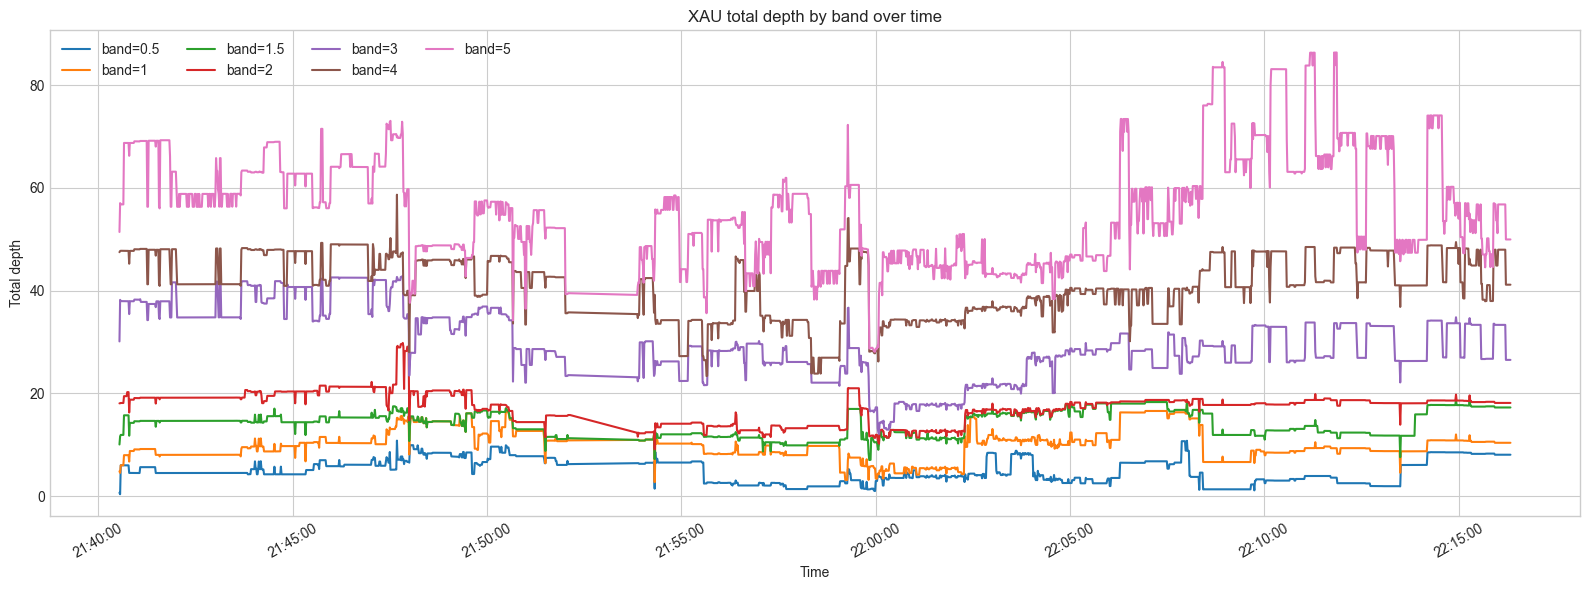

In [25]:
plot_multiband_lines(
    df,
    band_series("total_depth", DEPTH_BANDS),
    title="XAU total depth by band over time",
    ylabel="Total depth",
)

## Chart 2: rolling volatility of total depth

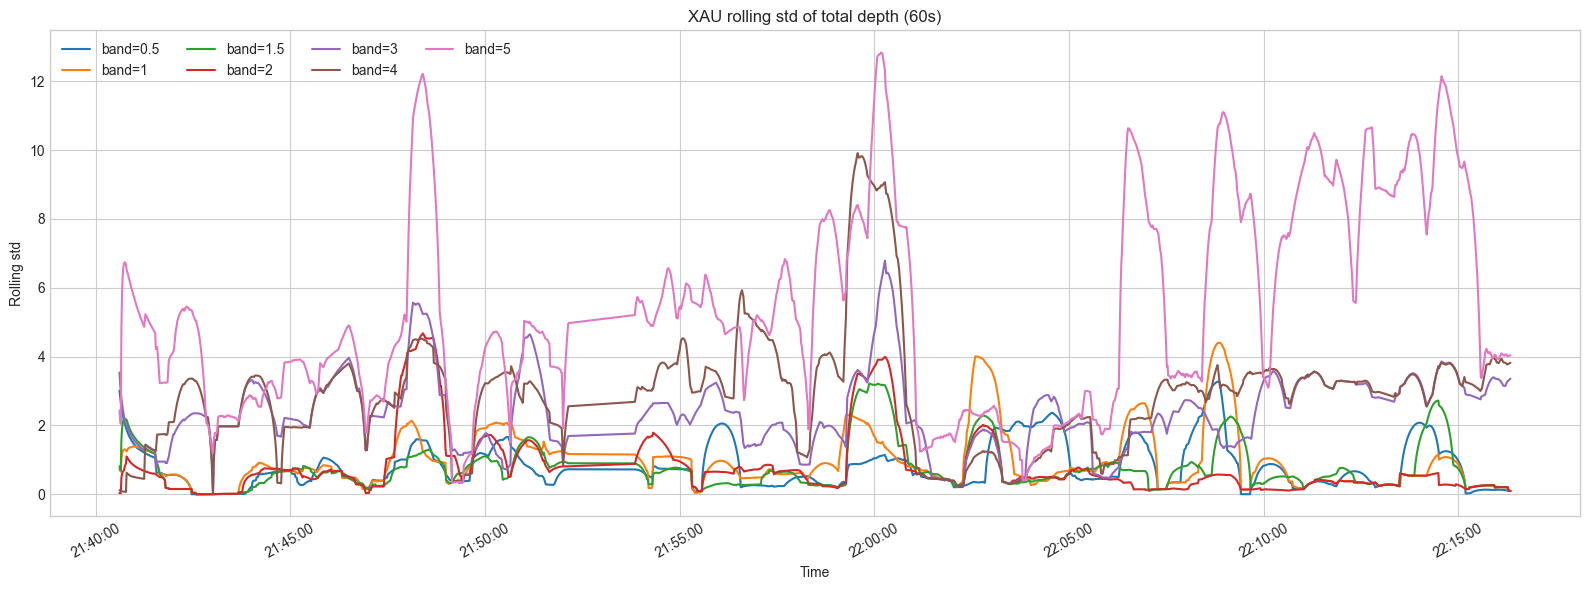

In [26]:
plot_multiband_lines(
    df,
    band_series(f"rolling_std_{DEFAULT_ROLLING_WINDOW}", DEPTH_BANDS),
    title=f"XAU rolling std of total depth ({DEFAULT_ROLLING_WINDOW})",
    ylabel="Rolling std",
)

## Chart 3: heatmap of absolute 1-second depth change

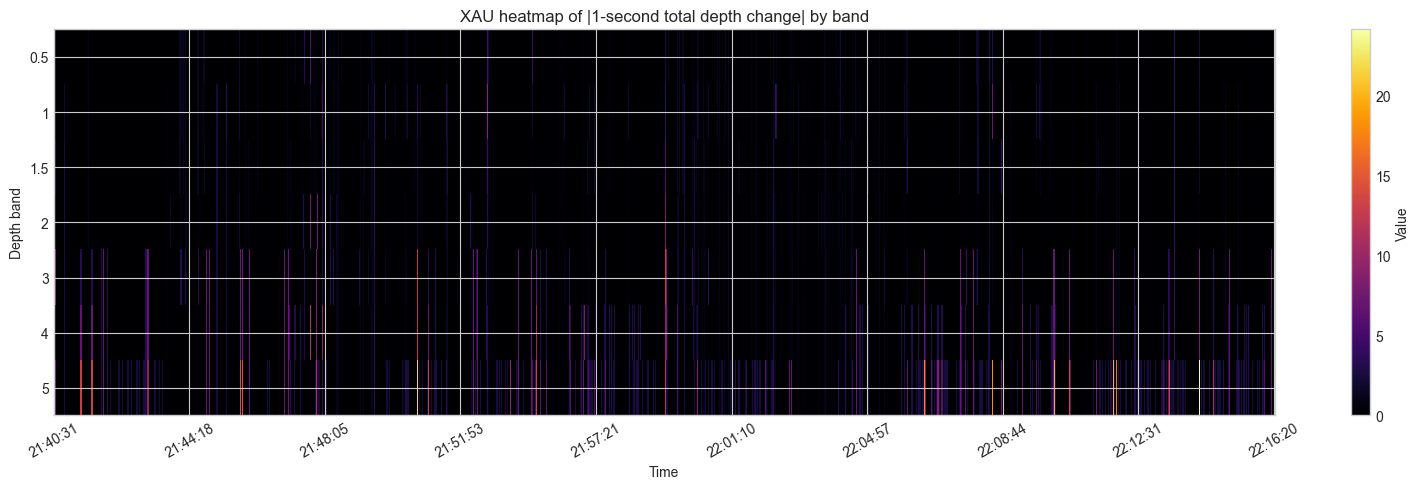

In [27]:
plot_heatmap(
    df,
    band_series("abs_depth_change_1s", DEPTH_BANDS),
    title="XAU heatmap of |1-second total depth change| by band",
    cmap="inferno",
)

## Chart 4: spread and depth volatility context

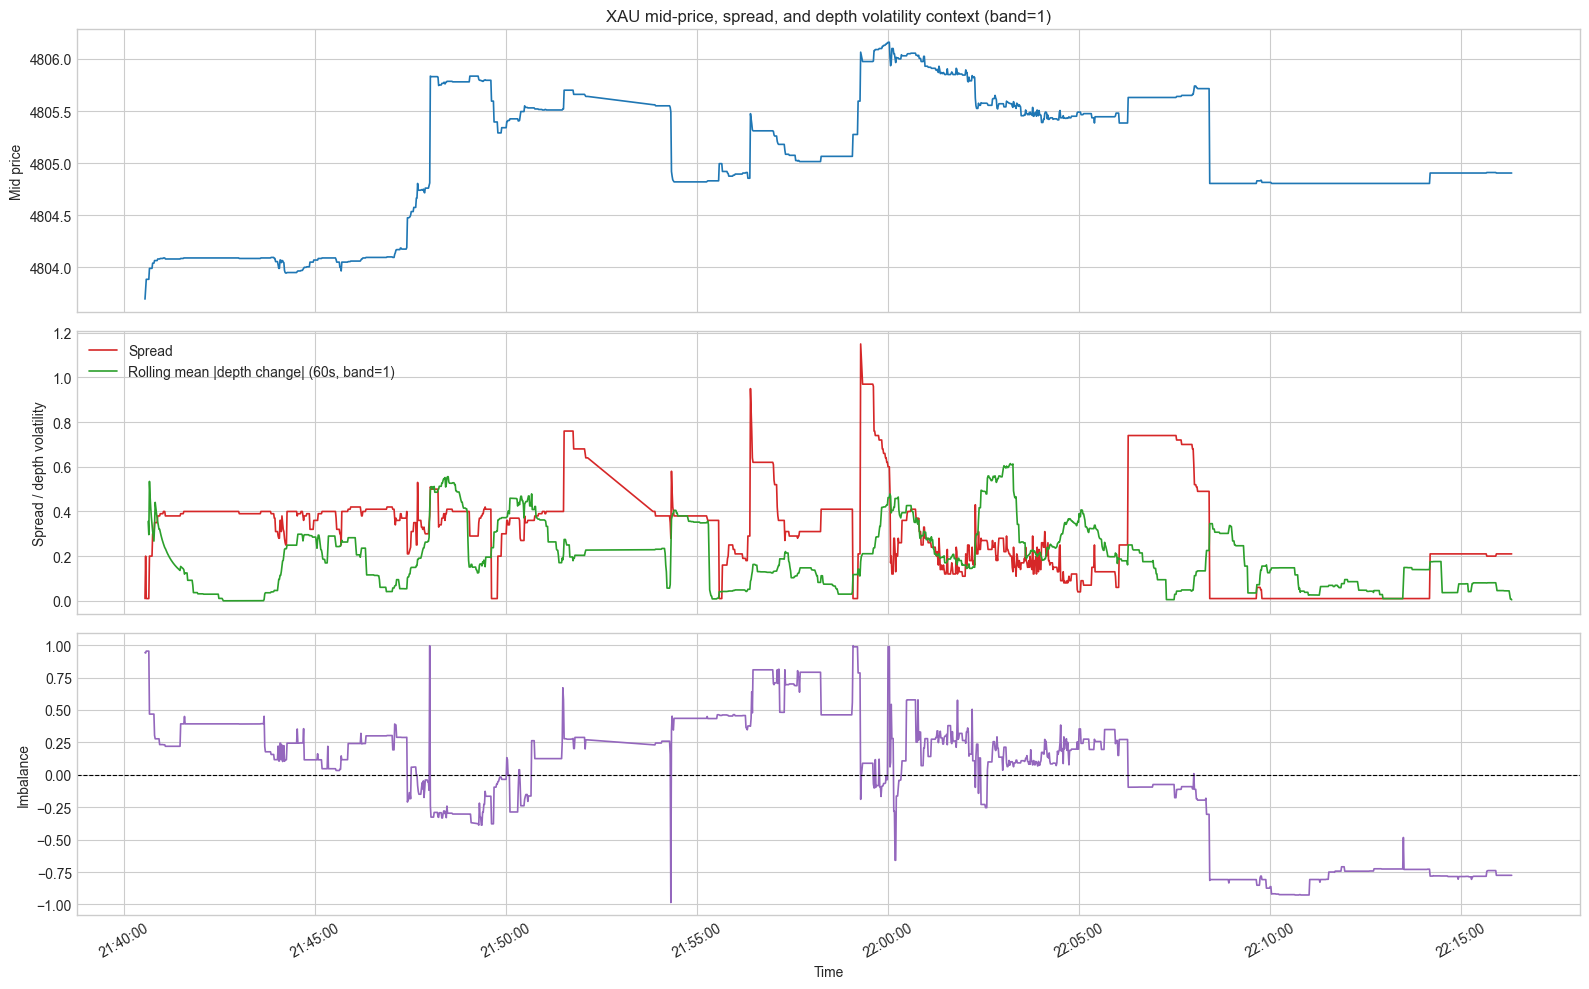

In [28]:
context_suffix = band_label(CONTEXT_BAND)
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

axes[0].plot(df["timestamp"], df["mid_price"], color="tab:blue", linewidth=1.2)
axes[0].set_title(f"XAU mid-price, spread, and depth volatility context (band={CONTEXT_BAND})")
axes[0].set_ylabel("Mid price")

axes[1].plot(df["timestamp"], df["spread"], color="tab:red", linewidth=1.2, label="Spread")
axes[1].plot(
    df["timestamp"],
    df[f"rolling_mean_abs_change_{DEFAULT_ROLLING_WINDOW}_{context_suffix}"],
    color="tab:green",
    linewidth=1.2,
    label=f"Rolling mean |depth change| ({DEFAULT_ROLLING_WINDOW}, band={CONTEXT_BAND})",
)
axes[1].set_ylabel("Spread / depth volatility")
axes[1].legend(loc="upper left")

axes[2].plot(
    df["timestamp"],
    df[f"imbalance_{context_suffix}"],
    color="tab:purple",
    linewidth=1.2,
)
axes[2].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[2].set_ylabel("Imbalance")
axes[2].set_xlabel("Time")

format_time_axis(axes[2])
plt.tight_layout()
plt.show()

## Chart 5: bid vs ask depth for key bands

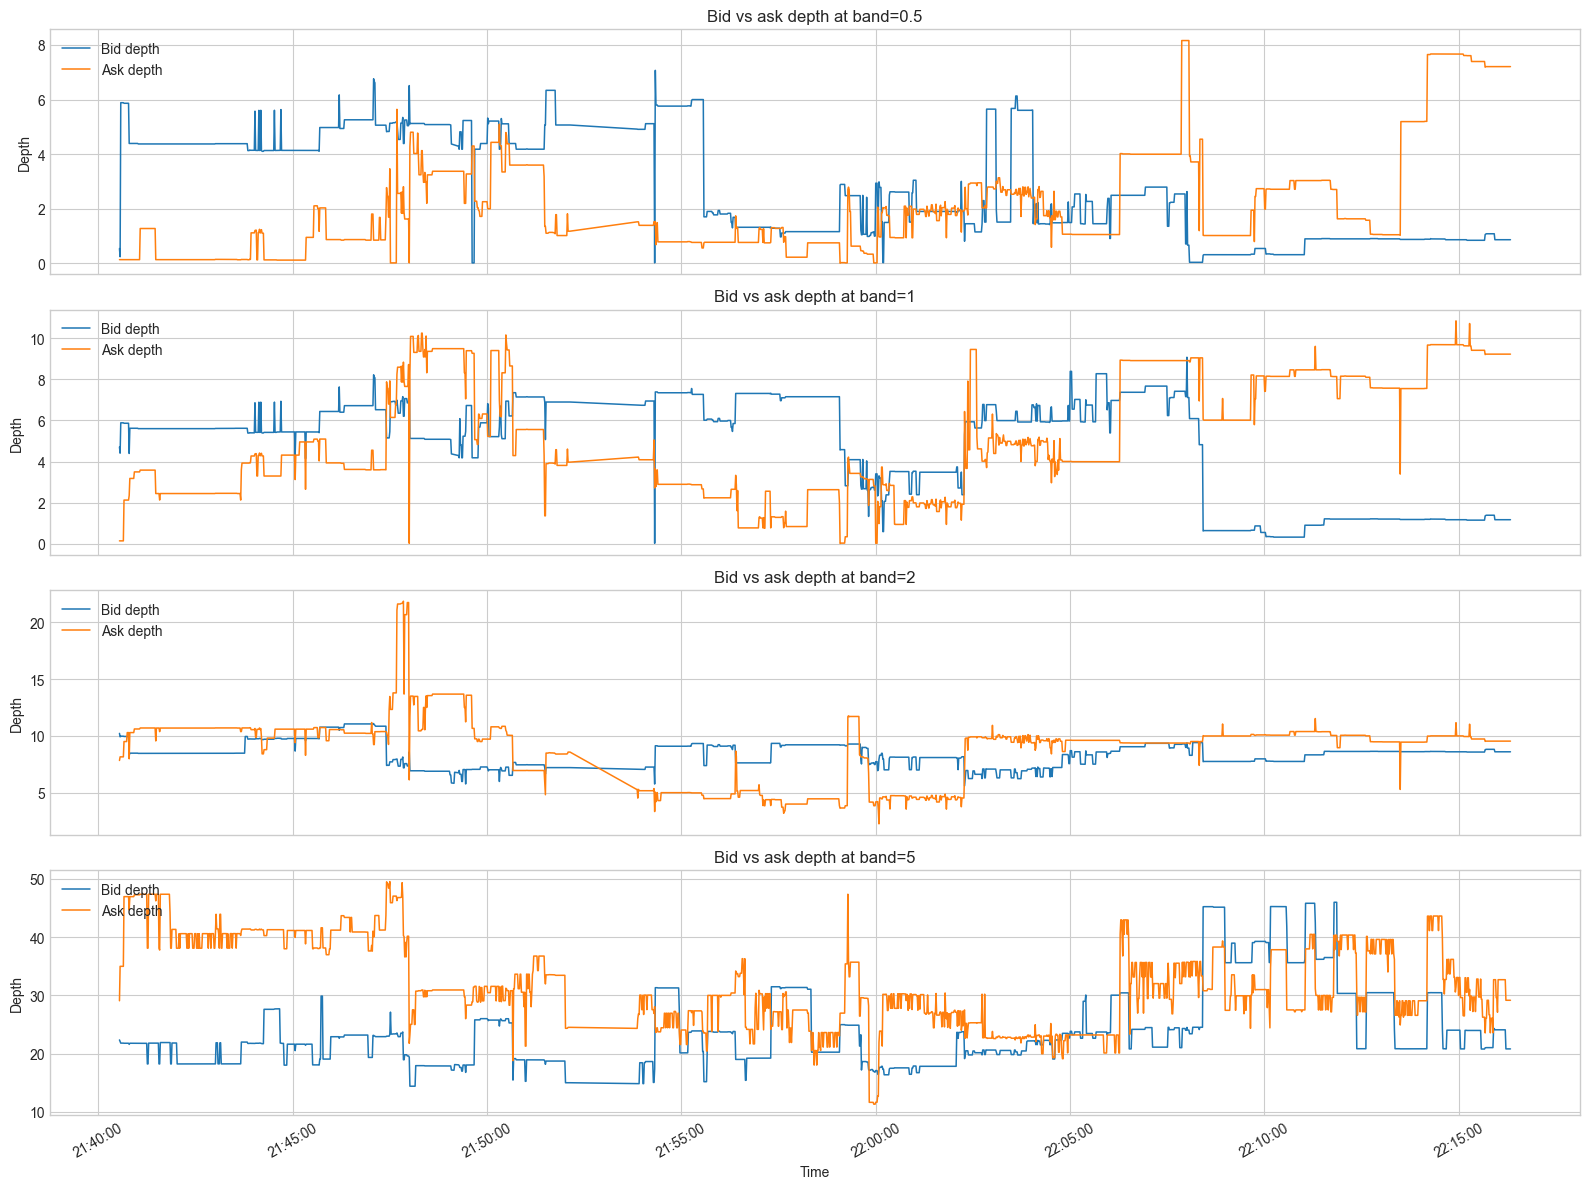

In [29]:
fig, axes = plt.subplots(len(KEY_BANDS), 1, figsize=(16, 3 * len(KEY_BANDS)), sharex=True)
if len(KEY_BANDS) == 1:
    axes = [axes]

for ax, band in zip(axes, KEY_BANDS):
    suffix = band_label(band)
    ax.plot(df["timestamp"], df[f"bid_depth_{suffix}"], label="Bid depth", linewidth=1.1)
    ax.plot(df["timestamp"], df[f"ask_depth_{suffix}"], label="Ask depth", linewidth=1.1)
    ax.set_title(f"Bid vs ask depth at band={band}")
    ax.set_ylabel("Depth")
    ax.legend(loc="upper left")

format_time_axis(axes[-1])
axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

## Which band is most volatile?

In [30]:
volatility_summary.style.format({
    "mean_total_depth": "{:.4f}",
    "mean_abs_depth_change_1s": "{:.4f}",
    f"mean_rolling_std_{DEFAULT_ROLLING_WINDOW}": "{:.4f}",
    "max_depth_spike": "{:.4f}",
}).background_gradient(subset=["mean_abs_depth_change_1s", f"mean_rolling_std_{DEFAULT_ROLLING_WINDOW}", "max_depth_spike"], cmap="YlOrRd")

,band,mean_total_depth,mean_abs_depth_change_1s,mean_rolling_std_60s,max_depth_spike
0,5.000000,56.0857,1.1876,5.3571,24.1658
1,4.000000,41.1279,0.5473,2.8936,16.7521
2,3.000000,29.8592,0.3784,2.3858,12.7469
3,1.000000,10.0183,0.1889,0.9565,9.2644
4,1.500000,14.1063,0.1562,0.7647,6.3815
5,2.000000,17.2955,0.1552,0.7965,14.3637
6,0.500000,4.9164,0.1355,0.8185,7.1424


## Top depth spikes

In [31]:
spike_frames = []
for band in DEPTH_BANDS:
    suffix = band_label(band)
    spike_frames.append(
        df[["timestamp", "spread", "mid_price", f"total_depth_{suffix}", f"abs_depth_change_1s_{suffix}"]]
        .rename(
            columns={
                f"total_depth_{suffix}": "total_depth",
                f"abs_depth_change_1s_{suffix}": "abs_depth_change_1s",
            }
        )
        .assign(band=band)
    )

top_spikes = (
    pd.concat(spike_frames, ignore_index=True)
    .sort_values("abs_depth_change_1s", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
top_spikes

,timestamp,spread,mid_price,total_depth,abs_depth_change_1s,band
0,2026-04-19 22:14:11.958000+07:00,0.21,4804.905,74.0717,24.1658,5.0
1,2026-04-19 22:12:37.863000+07:00,0.01,4804.805,70.6028,22.6449,5.0
2,2026-04-19 21:50:40.088000+07:00,0.36,4805.530,34.2283,21.8384,5.0
3,2026-04-19 22:06:17.500000+07:00,0.74,4805.630,70.9157,20.7802,5.0
4,2026-04-19 22:08:59.653000+07:00,0.01,4804.805,63.0476,20.4116,5.0
5,2026-04-19 22:11:47.816000+07:00,0.01,4804.805,86.3451,20.1942,5.0
6,2026-04-19 22:11:03.766000+07:00,0.01,4804.805,83.8096,20.1115,5.0
7,2026-04-19 22:10:09.711000+07:00,0.01,4804.805,80.0139,19.9502,5.0
8,2026-04-19 21:47:59.933000+07:00,0.38,4804.810,41.1226,18.6353,5.0
9,2026-04-19 22:08:25.622000+07:00,0.01,4804.805,76.0454,18.1903,5.0


## Optional: resample for readability when the series gets longer

In [32]:
resampled = (
    df.set_index("timestamp")
    .resample("10S")
    .agg({
        **{f"total_depth_{band_label(band)}": "mean" for band in DEPTH_BANDS},
        **{f"rolling_std_{DEFAULT_ROLLING_WINDOW}_{band_label(band)}": "mean" for band in DEPTH_BANDS},
        "spread": "mean",
        "mid_price": "last",
    })
    .dropna(how="all")
    .reset_index()
)
resampled.head()

ValueError: Invalid frequency: 10S. Failed to parse with error message: ValueError("Invalid frequency: S. Failed to parse with error message: KeyError('S'). Did you mean s?")

Nếu dữ liệu dài hơn, có thể thay `df` bằng `resampled` trong các hàm plot để đọc chart dễ hơn mà vẫn giữ được cấu trúc phân tích.